# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid



In [2]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw.csv to cars_hw.csv


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_6602/3836543585.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['No_of_Owners'] = df['No_of_Owners'].str.extract('(\d+)').astype(float)


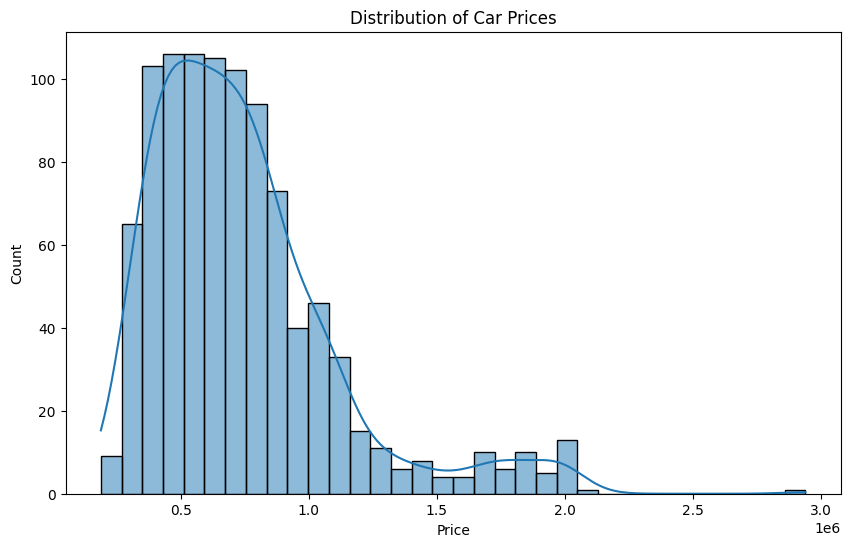

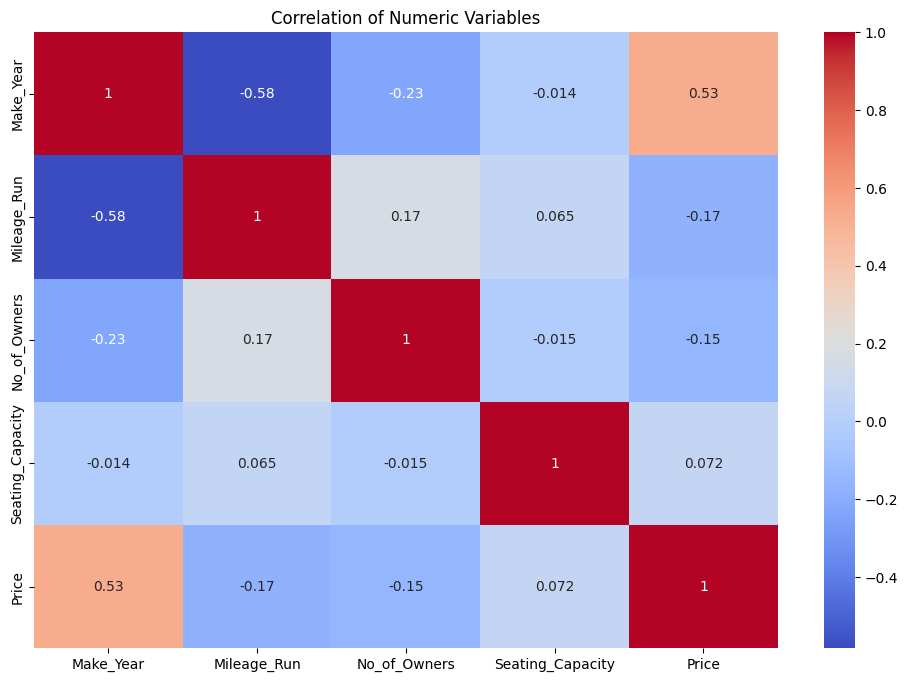

In [3]:
df = pd.read_csv('cars_hw.csv', index_col=0)

#wantedtoconvertnumberofownersto anumericvariable
df['No_of_Owners'] = df['No_of_Owners'].str.extract('(\d+)').astype(float)
#dropmissing
df = df.dropna()


plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Car Prices')
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation of Numeric Variables')
plt.show()


In [5]:
categorical = ['Make', 'Body_Type', 'Fuel_Type', 'Transmission_Type']
df_encoded = pd.get_dummies(df, columns=categorical, drop_first=True)

In [6]:
#80-20 train test split
X = df_encoded.drop('Price', axis=1)

X = X.select_dtypes(include=[np.number])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
simple_lin = LinearRegression()
simple_lin.fit(X_train, y_train)

def evaluate(model, X_train, X_test, y_train, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print(f"--- {name} ---")
    print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.2f}")
    print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_pred)):.2f}")
    print(f"Train R2: {r2_score(y_train, train_pred):.4f}")
    print(f"Test R2: {r2_score(y_test, test_pred):.4f}\n")

evaluate(simple_lin, X_train, X_test, y_train, y_test, "Simple Linear Model")

--- Simple Linear Model ---
Train RMSE: 308974.06
Test RMSE: 284940.59
Train R2: 0.3161
Test R2: 0.2921



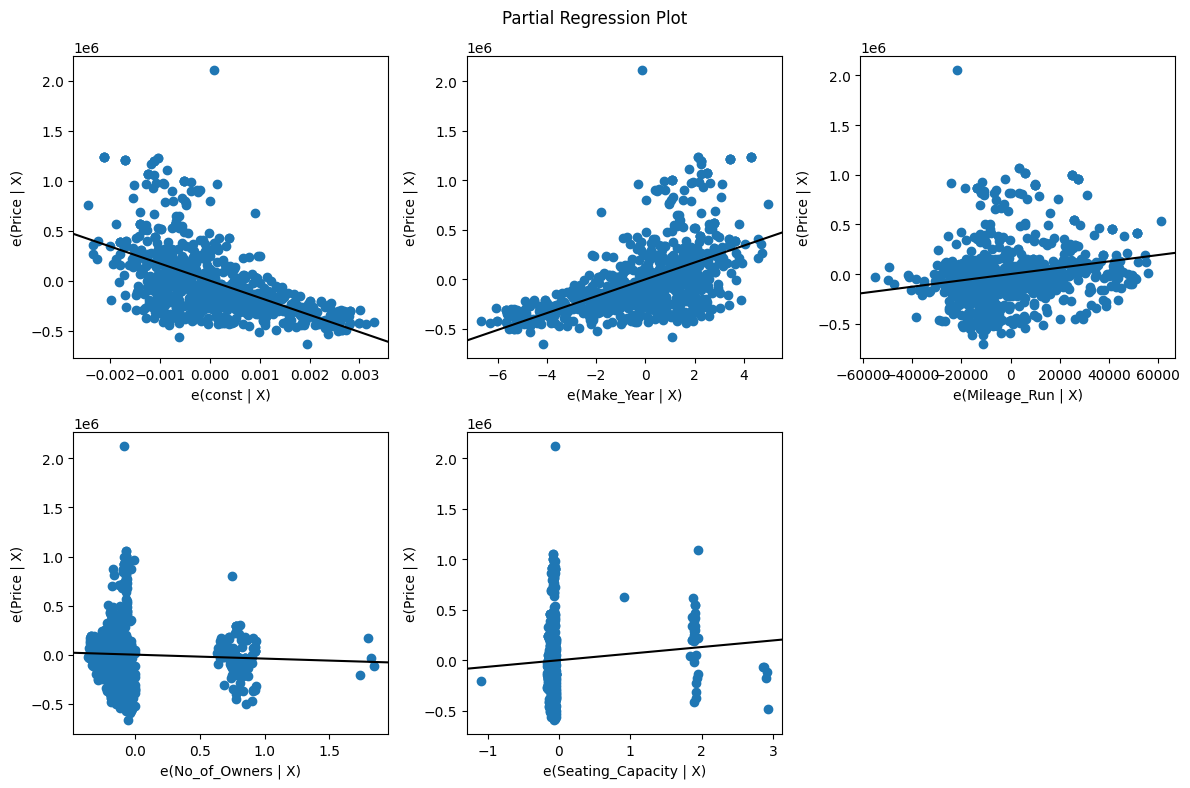

In [13]:
import statsmodels.api as sm
#had to look this part up as I kept getting Value and Attribute errors!

X_train_sm = sm.add_constant(X_train)


sm_model = sm.OLS(y_train, X_train_sm).fit()


fig = plt.figure(figsize=(12, 8))


sm.graphics.plot_partregress_grid(sm_model, fig=fig, grid=(2, 3))

plt.tight_layout()
plt.show()

In [17]:
X_train_complex = X_train.copy()
X_test_complex = X_test.copy()

X_train_complex['Year_Mileage_Inter'] = X_train['Make_Year'] * X_train['Mileage_Run']
X_test_complex['Year_Mileage_Inter'] = X_test['Make_Year'] * X_test['Mileage_Run']

# Term for mileage
X_train_complex['Mileage_Sq'] = X_train['Mileage_Run']**2
X_test_complex['Mileage_Sq'] = X_test['Mileage_Run']**2

complex_model = LinearRegression()
complex_model.fit(X_train_complex, y_train)


evaluate(complex_model, X_train_complex, X_test_complex, y_train, y_test, "Complex Model")

--- Complex Model ---
Train RMSE: 306305.18
Test RMSE: 281045.50
Train R2: 0.3278
Test R2: 0.3113



Summary of steps 1-6:

Through this lab I processed the car sales data, beginning with cleaning and encoding categorical variables and then creating a baseline to evaluate asset value through both simple linear model and complex model. The simple linear model offered an initial understanding of feature weights, but incorporating interaction terms like the relationship between car age and mileage and polynomial transformations allowed the complex model to capture non-linear trends more accurately. Relying on train-test splits and RMSE and R^2 to assess the functionality of the model. Based on this I figured out increasing complexity can significantly improve training accuracy, but can often lead to overfitting.